In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Linear Regression

In [5]:
load_diabetes[x]

NameError: name 'x' is not defined

In [2]:
X = np.array([1,3,4])
y = np.array([2,4,8])
X.shape, y.shape

((3,), (3,))

In [6]:
w = 1.5
b = 1

# Predict $\hat{y}$

In [7]:
def predict_y(X, w, b):
    m = X.shape[0]
    y_hat = np.zeros(m)

    for i in range(m):
        y_hat[i] = w * X[i] + b
    return y_hat

In [8]:
predict_y(X, w, b)

array([2.5, 5.5, 7. ])

In [13]:
def plot_real_vs_prediction(X, w, b):
    y_hat = predict_y(X, w, b)
    plt.scatter(X, y, label="real y")
    plt.plot(X,y_hat, label = "y_hat")
    plt.title("real vs predicted")
    plt.legend()

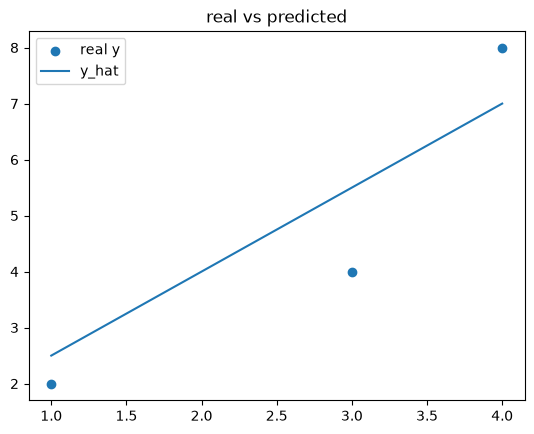

In [14]:
plot_real_vs_prediction(X, w, b)

# Mean square error
$$
MSE = 1/2m \sum_{i=1}^m (\hat{y} - y ) ^ 2
$$

## Calculate MSE

In [28]:
def calculate_mse(X, y, w, b):
    y_hat = predict_y(X, w, b)
    m = X.shape[0]
    sum  = np.sum((y_hat - y) ** 2)
    mse = (1/(2*m)) * sum
    return mse

In [29]:
calculate_mse(X, y, w, b)

np.float64(0.5833333333333333)

## Cost function
$$
J(w,b) =  1 / (2m) * \sum_{i=1}^n (\hat{y_i} - y_i ) ^ 2
$$
#### Although similar to cost function we can pass different w and b so see how the cost function behave Then we can use gradient descent to find local minima of the cost function. Thus obtained w and b will be optimal solution for our model

In [143]:
def gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = (1 / m) * np.sum((w * X + b - y) * X)
    dj_db = (1 / m) * np.sum(w * X + b - y)
    return (dj_dw, dj_db)

In [155]:
def gradient_descent(X, y, w, b, iters=1000, alpha=0.01, history_interval=100):
    history = {}
    for i in range(iters):
        dj_dw, dj_db = gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        if i % history_interval == 0:
            print(f"w {w}, b {b}")
            cost = calculate_mse(X, y, w, b)
            history[i] = cost;
            print(f"{i} => {cost}")
    return w, b
            

In [156]:
w_new, b_new = gradient_descent(X,y,w,b)

w 1.4966666666666666, b 0.9966666666666667
0 => 0.5811944444444446
w 1.518912141037045, b 0.7927796168922542
100 => 0.5331333459418242
w 1.5700206654454913, b 0.6298080473591114
200 => 0.5039202524118163
w 1.6134076705560356, b 0.4914635607214387
300 => 0.4828688764164708
w 1.6502384698064088, b 0.3740242954074911
400 => 0.4676989516331068
w 1.6815037707287952, b 0.2743312655282415
500 => 0.45676728531429633
w 1.708044575209364, b 0.18970283925244627
600 => 0.44888976909636125
w 1.7305748014248243, b 0.11786260586208396
700 => 0.4432131174355751
w 1.7497004874488273, b 0.0568781428311565
800 => 0.43912244047771154
w 1.765936093003366, b 0.005109035804988671
900 => 0.43617463973644127


In [157]:
print(f"Old mse {calculate_mse(X, y, w, b)}")
print(f"New mse {calculate_mse(X, y, w_new, b_new)}")

Old mse 0.5833333333333333
New mse 0.434068393450958


In [158]:
y_hat = predict_y(X, w_new, b_new)

In [159]:
y_hat

array([1.74115893, 5.30034171, 7.0799331 ])

In [160]:
y

array([2, 4, 8])

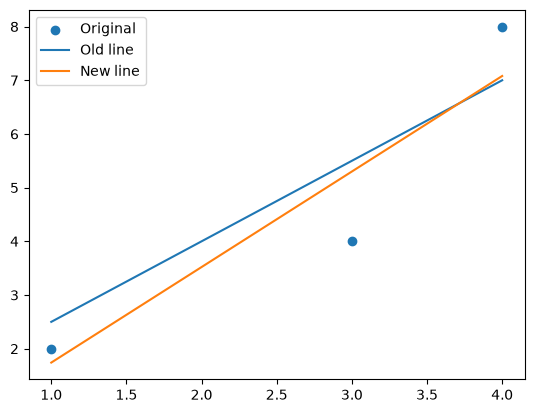

In [164]:
y_hat_old = predict_y(X, w, b)
y_hat_new = predict_y(X, w_new, b_new)
plt.scatter(X, y, label="Original")
plt.plot(X, y_hat_old, label="Old line")
plt.plot(X, y_hat_new, label="New line")
plt.legend()
plt.show()

# Fitting for large data set

In [166]:
m = 20
target_m = 4.4
target_b = 5
X = np.random.uniform(-10, 10, m)
noise = np.random.uniform(-3,3, m)
Y = X*target_m + target_b + noise
w = 3
b = 9

In [170]:
w_new, b_new = gradient_descent(X, Y, w, b, 10000)

w 3.2133744674834266, b 8.979707788432837
0 => 14.472218080277285
w 4.152635954923796, b 6.769354879612059
100 => 2.4372041620000746
w 4.214578888397569, b 5.8588075448806345
200 => 1.5515174283902873
w 4.239493920555917, b 5.492562117556069
300 => 1.4082262326402002
w 4.24951538374795, b 5.345248839136167
400 => 1.385043807071054
w 4.25354627256523, b 5.28599567068749
500 => 1.3812932287298247
w 4.255167599146581, b 5.262162530804472
600 => 1.3806864398564291
w 4.255819738166672, b 5.252576232357408
700 => 1.380588270266734
w 4.256082045160475, b 5.248720377930866
800 => 1.3805723878589258
w 4.256187551742472, b 5.247169454658368
900 => 1.380569818316987
w 4.256229989188319, b 5.246545633649821
1000 => 1.3805694026025779
w 4.2562470586144725, b 5.246294716884563
1100 => 1.38056933534605
w 4.256253924374261, b 5.246193791743812
1200 => 1.3805693244649246
w 4.256256685958454, b 5.246153197070816
1300 => 1.3805693227045168
w 4.25625779673825, b 5.2461368688550385
1400 => 1.38056932241970

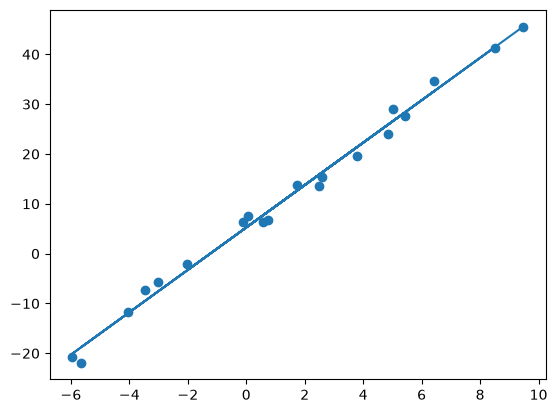

In [171]:
plt.scatter(X, Y)
plt.plot(X, predict_y(X, w_new, b_new))

In [172]:
w_new, b_new

(np.float64(4.256258544150694), np.float64(5.246125882058451))